---
title: "Handling Time Series Data & Modeling with an Interaction Term" 
---

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Working with Time Series Data

The company I picked is "The a2 Milk Company Limited ADR", with the ticker ACOPY. I chose this company as they are an NZ company who sell a specific type of a2 protein milk that I used to purchase when I was living in NZ. 

Download ACOPY data from Nasdaq website

In [2]:
a2data = pd.read_csv('HistoricalData_1763422872044.csv', index_col='Date', parse_dates=True)
a2data = a2data.rename(columns={'Close/Last': 'Close'})
a2data.head()

,Close,Volume,Open,High,Low
Date,,,,,
2025-11-14,$6.03,NaN,$6.03,$6.03,$6.03
2025-11-13,$6.03,11348.0,$5.91,$6.03,$5.91
2025-11-12,$6.2135,6010.0,$6.17,$6.2135,$6.17
2025-11-11,$6.11,5615.0,$6.27,$6.44,$6.11
2025-11-10,$6.14,13111.0,$6.19,$6.385,$6.14


In [3]:
a2data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249 entries, 2025-11-14 to 2024-11-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   249 non-null    object 
 1   Volume  83 non-null     float64
 2   Open    249 non-null    object 
 3   High    249 non-null    object 
 4   Low     249 non-null    object 
dtypes: float64(1), object(4)
memory usage: 11.7+ KB


Yes, the dataframe is indexed by time values, as the info output above demonstrates that the data has 249 date entries between 2025-11-14 and 2024-11-18.

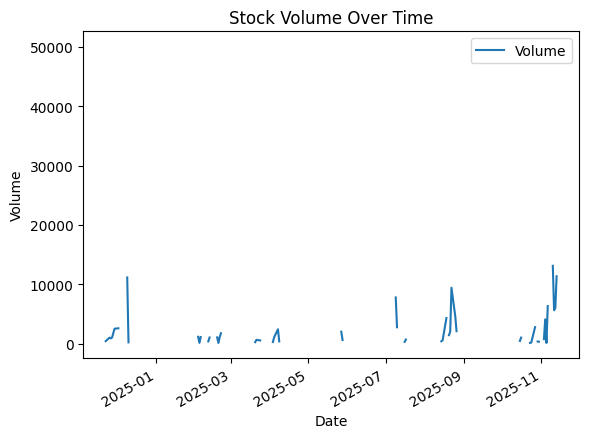

In [4]:
stockvolume = a2data.plot()
stockvolume.set_title('Stock Volume Over Time')
stockvolume.set_xlabel('Date')
stockvolume.set_ylabel('Volume')
plt.show()

This graph is attempting to show the volume that the company produced over the given period of time. It is a difficult graph to interpret because there are gaps between segements of the data, making it difficult to interpret the output.It would be easier to understand if the data was complete so that we could see one continuous line of the data.

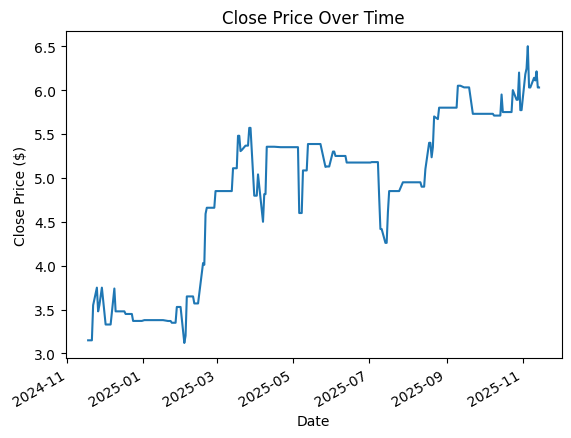

In [5]:
a2data['Close'] = a2data['Close'].replace('[$,]', '', regex=True).astype(float)
a2data['Close'].plot()
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.show()

From this graph we can see the closing price plotted on the y-axis and the date plotted on the x-axis. The data shows a general upward trend in the closing price where it began at \$3.0 in November 2024, and current closes at around \$6.0 in November 2024. The data fluctuates over this period of time, but there are two notable increases in price between march and april 2025, from \$3.50 to \$5.50. Another large increase occurs from september to october 2025 where the price went from \$5.00 to \$6.00.

This graph is much easier to interpret because the data is complete, meaning we can see one continuous line from throughout the 12 month period, allowing us to analyze the overall trend and any major changes that occur.

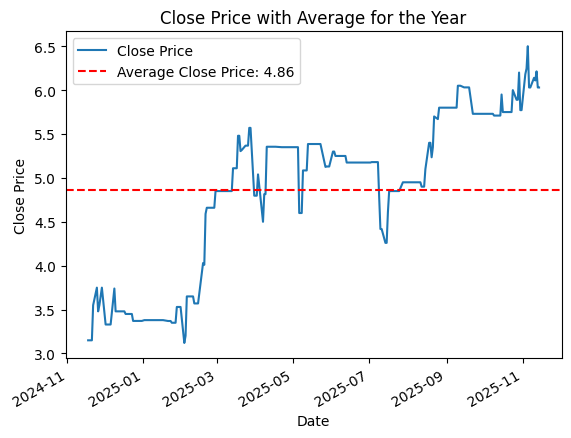

In [30]:
average_close_price = a2data['Close'].mean()
a2data['Close'].plot(label='Close Price')

plt.axhline(y=average_close_price, color='r', linestyle='--', label=f'Average Close Price: {average_close_price:.2f}')
plt.title('Close Price with Average for the Year')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

This horizontal line showing the average price allows us to see the period of time within the last 12 months where the closing period was below and above average. This base line average price line indicates how the a close price at any given time throughout the last 12 months compares with the average, indicating its performance.

In [7]:
a2data['daily_change'] = a2data['Close'].diff()
a2data.head()

,Close,Volume,Open,High,Low,daily_change
Date,,,,,,
2025-11-14,6.0300,NaN,$6.03,$6.03,$6.03,NaN
2025-11-13,6.0300,11348.0,$5.91,$6.03,$5.91,0.0000
2025-11-12,6.2135,6010.0,$6.17,$6.2135,$6.17,0.1835
2025-11-11,6.1100,5615.0,$6.27,$6.44,$6.11,-0.1035
2025-11-10,6.1400,13111.0,$6.19,$6.385,$6.14,0.0300


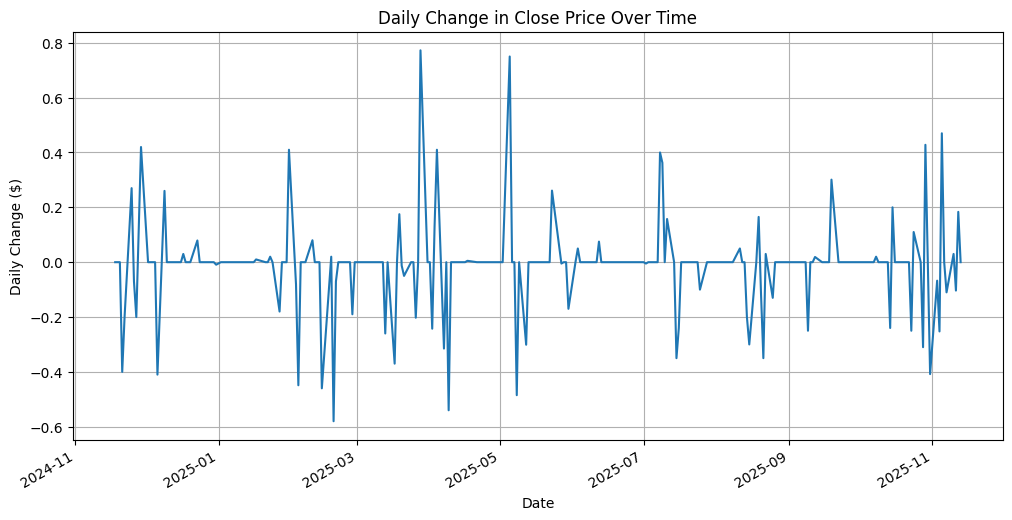

In [33]:
a2data['daily_change'].plot(figsize=(12, 6))
plt.title('Daily Change in Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Change ($)')
plt.grid(True)
plt.show()

This graph allows us to see the daily flucations to gain an understanding of the magnitude and direction for the changes in price each day, which is not as clearly understood in the closing price over time plot. The original plot shows the price and trends over time, while this plot with the daily change focuses purely on volatility of the price.

The periods that showed the most volatility and prominent price changes were between March-April 2025. During this period there are daily price changes ranging from either -0.50 and +0.80 each respective day. This corresponds with a major upward trend in the closing price. A similar trend occurs between September-October 2025, where there is another increase in the daily closing price, but the changes here only range from -0.4 to +0.4. Additionally, there are also periods where the change is close to or exacty 0. This occurs in December - January 2025 and July - August 2025. These time periods represent times of stability and low price movement

Text(0, 0.5, 'Close Price')

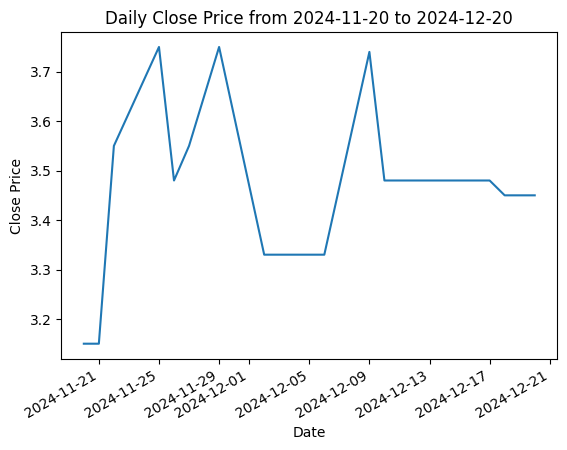

In [8]:
a2data = a2data.sort_index()
plt = a2data.loc['2024-11-20':'2024-12-20', 'Close'].plot()
plt.set_title('Daily Close Price from 2024-11-20 to 2024-12-20')
plt.set_xlabel('Date')
plt.set_ylabel('Close Price')

This plot gives a micro view at the closing price for on a daily level, for the specified timeframe. This allows us to see minor changes that occur day-to-day that we were not able to closely analyze on the previous graph. Throughout this month, we can see that on a daily level, the biggest change in the closing price was about \$0.30, with the entire month fluctuating between just below \$3.20 and \$3.70. Based on this snapshot, and the other graph, there is no clear movements or trends that would seem unusual.

Text(0, 0.5, 'Close Price')

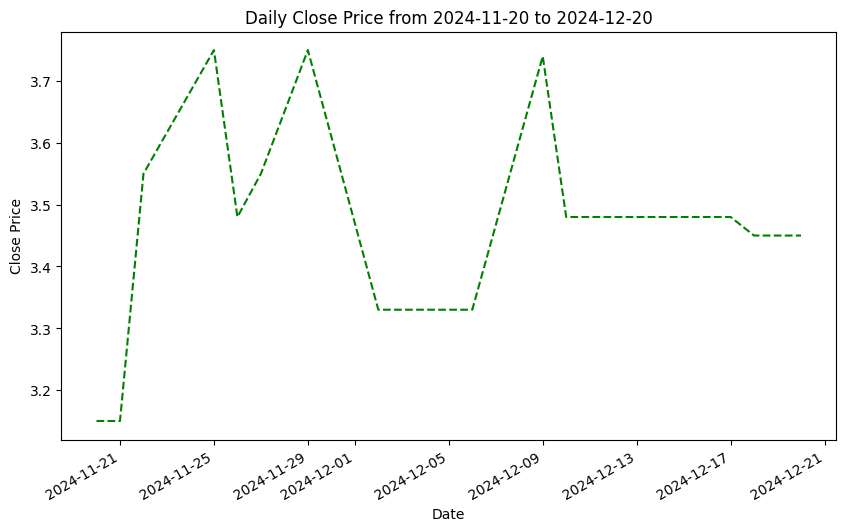

In [9]:
a2data = a2data.sort_index()
plt = a2data.loc['2024-11-20':'2024-12-20', 'Close'].plot(figsize=(10, 6), color='green', style='--')
plt.set_title('Daily Close Price from 2024-11-20 to 2024-12-20')
plt.set_xlabel('Date')
plt.set_ylabel('Close Price')

In [10]:
a2data['MA_20'] = a2data['Close'].rolling(window=20).mean()
a2data.head()

,Close,Volume,Open,High,Low,daily_change,MA_20
Date,,,,,,,
2024-11-18,3.15,NaN,$3.15,$3.15,$3.15,0.0,NaN
2024-11-19,3.15,NaN,$3.15,$3.15,$3.15,0.0,NaN
2024-11-20,3.15,NaN,$3.15,$3.15,$3.15,0.0,NaN
2024-11-21,3.15,NaN,$3.15,$3.15,$3.15,-0.4,NaN
2024-11-22,3.55,400.0,$3.55,$3.55,$3.55,-0.2,NaN


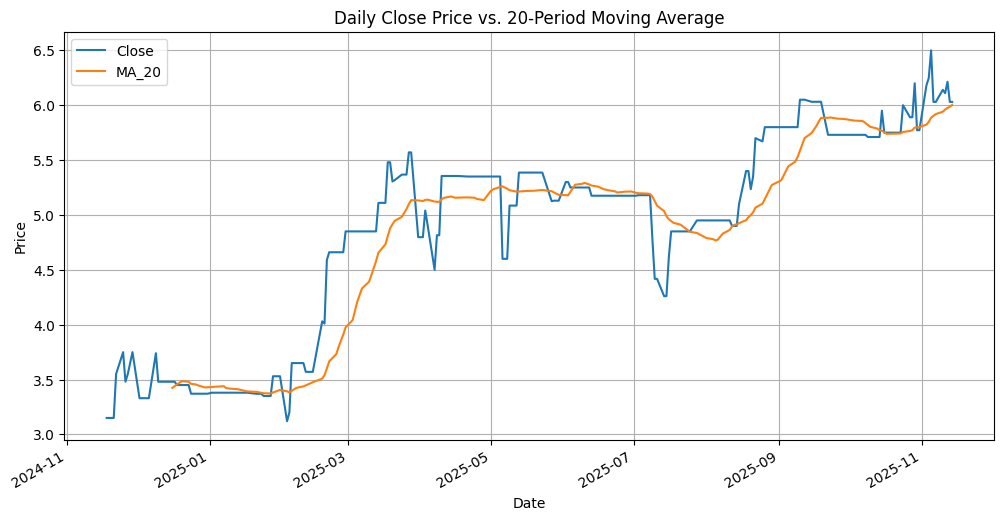

In [11]:
ax = a2data[['Close', 'MA_20']].plot(figsize=(12, 6))
ax.set_title('Daily Close Price vs. 20-Period Moving Average')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True)
plt.show()

In [12]:
a2data['MA_75'] = a2data['Close'].rolling(window=75).mean()
a2data.head()

,Close,Volume,Open,High,Low,daily_change,MA_20,MA_75
Date,,,,,,,,
2024-11-18,3.15,NaN,$3.15,$3.15,$3.15,0.0,NaN,NaN
2024-11-19,3.15,NaN,$3.15,$3.15,$3.15,0.0,NaN,NaN
2024-11-20,3.15,NaN,$3.15,$3.15,$3.15,0.0,NaN,NaN
2024-11-21,3.15,NaN,$3.15,$3.15,$3.15,-0.4,NaN,NaN
2024-11-22,3.55,400.0,$3.55,$3.55,$3.55,-0.2,NaN,NaN


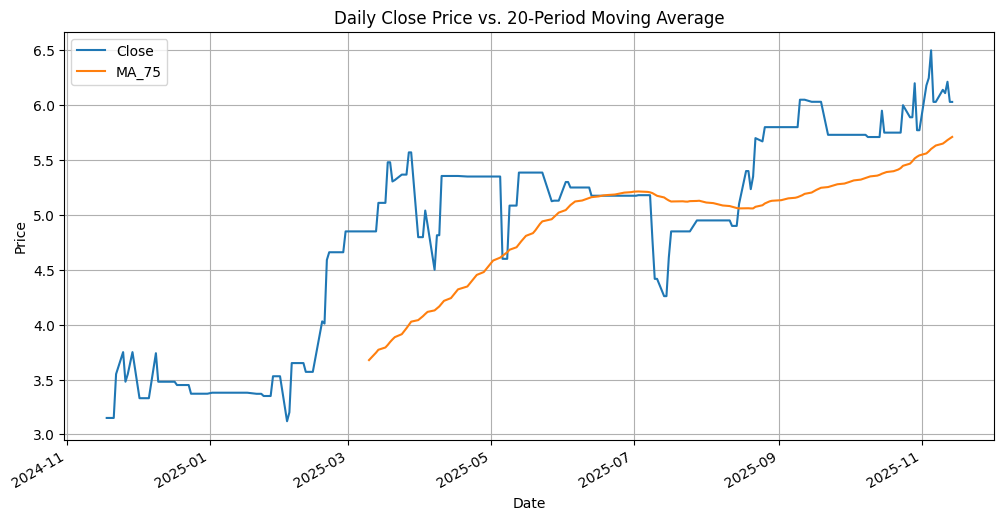

In [13]:
a2data[['Close', 'MA_75']].plot(figsize=(12, 6))
plt.title('Daily Close Price vs. 20-Period Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

The two plots demonstrates differences based on the time frames on the moving averages. The 20-day moving average is a more short-term (less than a month), meaning it will be more responsive to the recent price changes and will generally track closer of the actual data points. The 75-day moving average is a more medium-term (closer to 3 months), meaning that it is less responsive to recent price changes and will plot a smoother trend. This is reflected in the plots above, with the 20-day moving average following more closely, reflecting a higher sensitivity to the datas changes, whereas the 75-day moving average plots closer to a trend line, reflecting lower sensitvity and filtering out major noise.

The 20-day average will reflect a quicker indication of changes due to its higher sensitivity, meaning it will be better at identifying short-term trends. However, it is prone to outliers or standalone values adding noise and false indications to its trends, meaning it is less reliable for long-term decisions.

The 75-day average will do the opposite, as it filters out the noise providing more reliable signals of trend changes making it useful for strategic decision making. However, due to its longer lead time and lower sensitvity, it can be delayed to reflect significant changes, meaning it is less useful for short-term trading decisions.

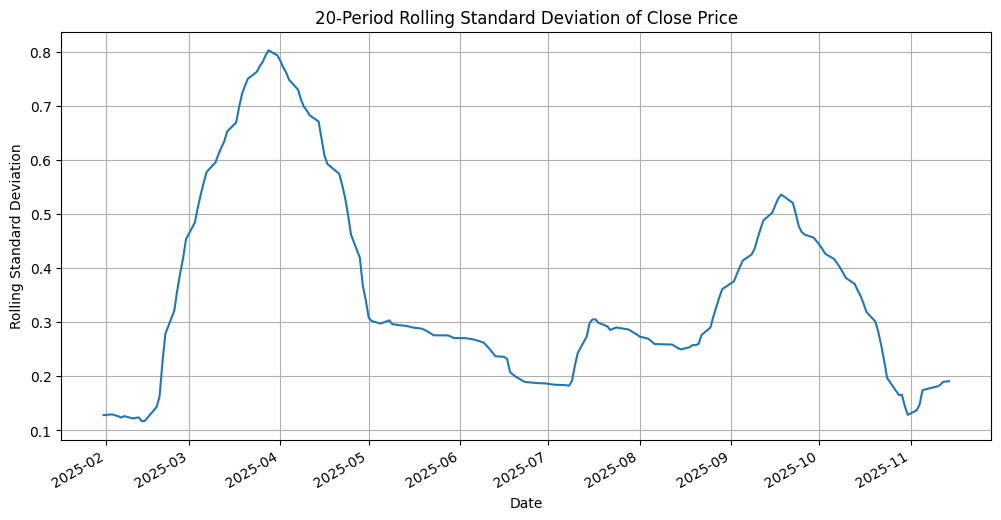

In [14]:
a2data['MA_20_std'] = a2data['Close'].rolling(window=50).std()
a2data['MA_20_std'].plot(figsize=(12, 6))
plt.title('20-Period Rolling Standard Deviation of Close Price')
plt.xlabel('Date')
plt.ylabel('Rolling Standard Deviation')
plt.grid(True)
plt.show()

The rolling standard deviation plot is produced over a 50-day moving average. From the graph, we can see there are two significant peaks where the standard deviation is large relative to the other data. Firstly, between march 2025 and june 2025, we can see the standard deviation grow from just over 0.1 to 0.8, before settling back down to 0.3. The standard deviation floats between 0.3 and just below 0.2 until september 2025, where it increases to just over 0.5 in between september and october, until it decreases back down to below 0.2 in november 2025. This shows that in the last 12 months, based on the 50-day moving averages there are two clear windows of deviation in the closing price. This is significant becauses the trend remains clear over this 50-day period.

In [15]:
a2data_quarterly_mean = a2data['Close'].resample('QE').mean()
print("Quarterly Mean Close Prices:")
print(a2data_quarterly_mean.head())

Quarterly Mean Close Prices:
Date
2024-12-31    3.420133
2025-03-31    4.193062
2025-06-30    5.191758
2025-09-30    5.312578
2025-12-31    5.900155
Freq: QE-DEC, Name: Close, dtype: float64


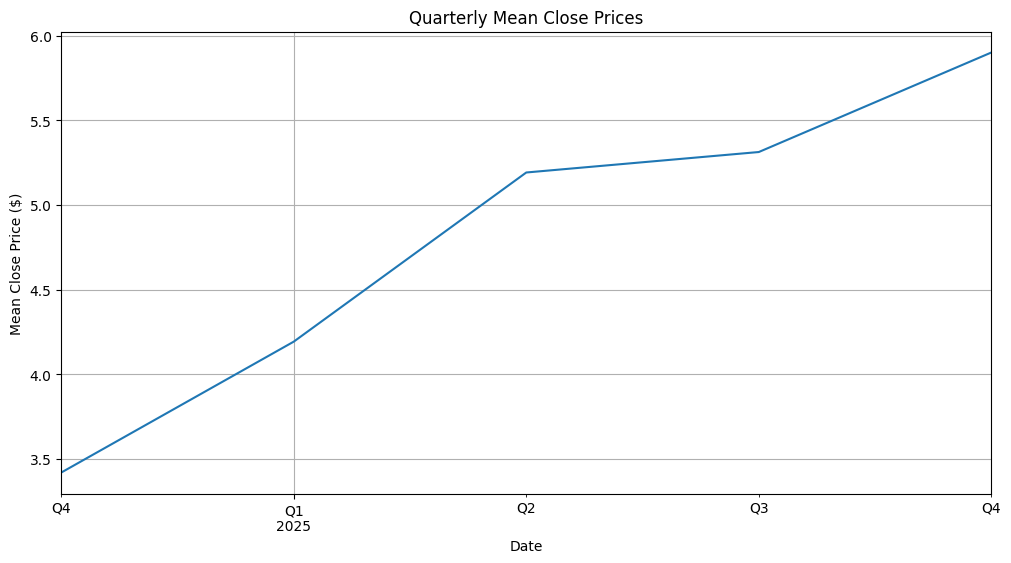

In [16]:
a2data_quarterly_mean.plot(figsize=(12, 6))
plt.title('Quarterly Mean Close Prices')
plt.xlabel('Date')
plt.ylabel('Mean Close Price ($)')
plt.grid(True)
plt.show()

An example of why someone might want to resample a time series data is in people analytics. People analytics is a function of analytics in business where they look at the compensation, performance and productivity of their employees. A specific example of how a resample might be used is to look at their employees average productivity, tracked by their hours worked (not a perfect measure, but reflects the idea). A company might want to look back over the past 10 years of data, but resample it to quarters from weeks to see the trends of what quarters their employees are working more as a starting point for further analysis. By adjusting the time frame thery are able to either get a macro or micro view on the variable they are plotting over time.

# Marketing Mix Modeling with an Interaction Term

In [17]:
lobstermarketing = pd.read_csv('marketing_campaign_lobster.csv')
lobstermarketing.head()

,influencer_spend,email_spend,radio_spend,conversions
0,28.97,62.85,28.73,45
1,134.30,61.11,74.28,194
2,140.56,9.43,33.48,100
3,72.38,21.88,76.27,73
4,64.35,81.06,49.26,112


In [18]:
lobstermarketing['total_spending'] = lobstermarketing['influencer_spend'] + lobstermarketing['email_spend'] + lobstermarketing['radio_spend']
lobstermarketing.head()

,influencer_spend,email_spend,radio_spend,conversions,total_spending
0,28.97,62.85,28.73,45,120.55
1,134.30,61.11,74.28,194,269.69
2,140.56,9.43,33.48,100,183.47
3,72.38,21.88,76.27,73,170.53
4,64.35,81.06,49.26,112,194.67


In [19]:
lobstermarketing.corr()

,influencer_spend,email_spend,radio_spend,conversions,total_spending
influencer_spend,1.000000,0.036761,0.113315,0.765166,0.790291
email_spend,0.036761,1.000000,0.083123,0.590165,0.510142
radio_spend,0.113315,0.083123,1.000000,0.151420,0.503005
conversions,0.765166,0.590165,0.151420,1.000000,0.883221
total_spending,0.790291,0.510142,0.503005,0.883221,1.000000


The correlation between the total spending and conversions is 0.88, reflecting a strong positive correlation - meaning that as the total spending increases, so does the conversions.

However, we cannot conclude that more ad spending will lead to more conversions, as total spends is a sum of the 3 different types. This means that different functions of the spending will influence the conversions. For example, the influencer and email  spend have higher correlation with conversions with 0.76 and 0.59 respectively, while radio spend only has a correlation of 0.15.

In [20]:
lobstermarketing[['email_spend', 'radio_spend', 'influencer_spend']].corr()

,email_spend,radio_spend,influencer_spend
email_spend,1.000000,0.083123,0.036761
radio_spend,0.083123,1.000000,0.113315
influencer_spend,0.036761,0.113315,1.000000


Based on the correlations between the individual spending categories, there are no correlations between these variables that would stop us from using them together in a linear model.

In [21]:
model_formula = 'conversions ~ influencer_spend + email_spend + radio_spend'
model = smf.ols(formula=model_formula, data=lobstermarketing)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            conversions   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     449.0
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           1.80e-73
Time:                        19:50:34   Log-Likelihood:                -679.66
No. Observations:                 150   AIC:                             1367.
Df Residuals:                     146   BIC:                             1379.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -72.2859      6.100  

The p-value of the F-statistic is 1.80e-78, which is a very small numbers. Based on statistical significance, this is a very low p-value which would be less than the typical beta threshold of 0.05 for the F-statistic. This mns that the predictive variables of each type of ad spend do a better job at predicting the conversions than could be done elsewise.

On an individual level, the influencer and email spends both have p-values shown as 0.000, meaning that they are also below the typical 0.05 beta threshold. This means that these values are statistically significant and are good predictors of the conversions. However, radio spend has a p-value of 0.430, which is above the 0.05 threshold, meaning that it is not a great predictor of the conversions.

In [22]:
lobstermarketing['email_spend_group'] = pd.qcut(lobstermarketing['email_spend'], q=3, labels=['low', 'medium', 'high'])

In [23]:
lobstermarketing.head(5)

,influencer_spend,email_spend,radio_spend,conversions,total_spending,email_spend_group
0,28.97,62.85,28.73,45,120.55,medium
1,134.30,61.11,74.28,194,269.69,medium
2,140.56,9.43,33.48,100,183.47,low
3,72.38,21.88,76.27,73,170.53,low
4,64.35,81.06,49.26,112,194.67,high


<Figure size 1200x600 with 0 Axes>

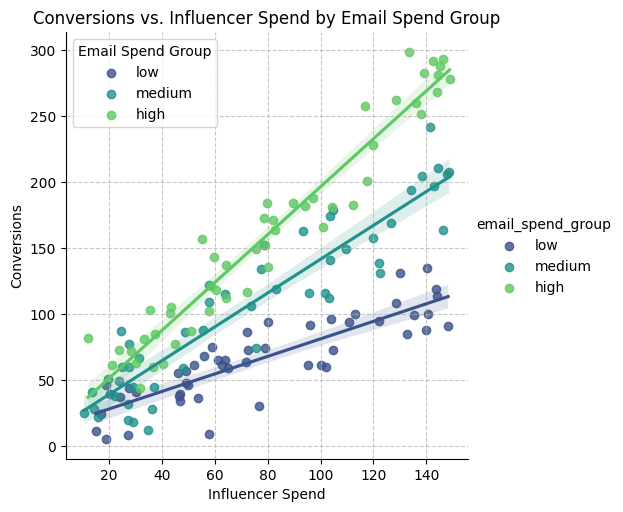

In [24]:
plt.figure(figsize=(12, 6))
sns.lmplot(
    data=lobstermarketing,
    x='influencer_spend',
    y='conversions',
    hue='email_spend_group',
    palette='viridis'
)
plt.title('Conversions vs. Influencer Spend by Email Spend Group')
plt.xlabel('Influencer Spend')
plt.ylabel('Conversions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Email Spend Group')
plt.show()


The different slopes show the impact that the email spend has on the conversion. Each line reflects the impact that the varying levels of email spend has on the conversions. High spend has the steepest curve, medium has a moderate curve and the low spend has a very steady curve. These demonstrate visual evidence suggesting a clear interaction and influence of the email spend. The lines would present closer to horizontal if there was no interaction, which would show that the higher spend does not influence the conversions.

In [25]:
lobstermarketing['interaction'] = lobstermarketing['influencer_spend'] * lobstermarketing['email_spend']

In [26]:
lobstermarketing.head(5)

,influencer_spend,email_spend,radio_spend,conversions,total_spending,email_spend_group,interaction
0,28.97,62.85,28.73,45,120.55,medium,1820.7645
1,134.30,61.11,74.28,194,269.69,medium,8207.0730
2,140.56,9.43,33.48,100,183.47,low,1325.4808
3,72.38,21.88,76.27,73,170.53,low,1583.6744
4,64.35,81.06,49.26,112,194.67,high,5216.2110


In [27]:
model_formula2 = 'conversions ~ influencer_spend + email_spend + interaction'
model2 = smf.ols(formula=model_formula2, data=lobstermarketing)
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:            conversions   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     1011.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           2.03e-97
Time:                        19:50:38   Log-Likelihood:                -622.98
No. Observations:                 150   AIC:                             1254.
Df Residuals:                     146   BIC:                             1266.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.4199      6.480  

The p-values for these predictors are all below the 0.05 threshold, meaning they all hold statistical significance towards this model.

In [32]:
model_formula3 = 'conversions ~ influencer_spend + email_spend'
model3 = smf.ols(formula=model_formula3, data=lobstermarketing)
results3 = model3.fit()
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:            conversions   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     674.9
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           8.37e-75
Time:                        20:06:48   Log-Likelihood:                -679.98
No. Observations:                 150   AIC:                             1366.
Df Residuals:                     147   BIC:                             1375.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -70.0311      5.387  

The r-squared value for the model with the interaction variables is 0.954, which is higher than the r-squared value in the model that did not have the interaction variable which is 0.902. This suggests that the inclusion of the interaction term explains more of the data as it explains a larger percentage of variation in the dependent variable. However, with a r-squared of 0.902, this is already a high-performing model, which maY mean the inclusion of the interaction variable leads to overfitting of the data to the model.

In [29]:
prediction_df = pd.DataFrame({
    'influencer_spend': [100],
    'email_spend': [50]
})

predicted_conversions = results3.predict(prediction_df)

print(f"Predicted conversions for 100 units of influencer spend and 50 units of email spend: {predicted_conversions.iloc[0]:.2f}")

Predicted conversions for 100 units of influencer spend and 50 units of email spend: 132.78


We would expect to see 132.78 conversions based on these level of ad spending.

When interpreting the effect between influencer and email spend from a marketing approach, we can see that they are both having a positive effect on the conversions being made. This is not only occuring on an individual level, because the interaction variable shows us that the combined effect of using both levels of spend drives an increase in conversions. From a marketing perspective, this is useful as it tells us that using both forms of ad spend is more beneficial then one of them alone. Lobsterland may use this information to use a combination of ad spent to their potential vistiors rather than relying purely on one method stand alone.

For my example of an interaction effect, I thought about my time as as an Athlete on the Boston University Men's Rowing Team. I always was very frustrated about how little time we spent in set crew line ups because we were always swapping around and doing mixed line ups (top guys and bottom guys all mixed into random crews for training). To explain further, the line up refers to the combination of both the rowers in the boat and the order in which people sit. Getting the right balance of both people and setting is both an art and a science, but what is more important is spending time in this combination. However, with 20hrs of training a week, we were inevitably spending a lot of time working on our fitness and strength, which goes a long way to being succesful and producing fast times but is never fully optimized without getting the line-up developed and meshed together overtime.

This lead me to think about how these two variable interact. Firstly, it is important for me to define the two variables and how I think of them.

Variables:
1. Days spent in the line: how mant days the exact crew has spent in the same line-up training together. This count as both the personnel and positioning in the boat. This only counts the days in the boat, on the water.
2. Average 2k erg score for the boat: the average 2k ergometer score for the 8 rowers in the boat. This is the base line fitness and strength measurement in rowing. It is performed on the land based machine.

Outcome Variable: The boats fastest 2k on water time. This is the baseline racing distance for rowing and the distance we competed over. A faster time reflect increased probability of winning races.

The idea here is that the interaction term of both a better average 2k score for the boat and the amount of days the crew has spent in a line up greatly exceeds the crews fastest 2k time on water more than just one of those variables by themselves. This shows that the effect of their interaction is a positive outcome. This interation makes sense to me as it is not purely either the technical cohesion or strength/fitness that make a fast rowing crew, but rather the interaction between them.


